# 03 — Label Mapping & Train/Test Split

Loads the extracted mel spectrograms, confirms the binary label distribution,
and creates a stratified 80/20 train/test split.

**Labels:** 0 = Transportation | 1 = Conversation

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

SPEC_DIR  = '../data/processed/spectrograms'
SPLIT_DIR = '../data/processed/train_test_split'
os.makedirs(SPLIT_DIR, exist_ok=True)

LABEL_NAMES = {0: 'Transportation', 1: 'Conversation'}
COLORS      = {0: 'tomato', 1: 'mediumseagreen'}

## 1. Load spectrograms

In [2]:
X = np.load(os.path.join(SPEC_DIR, 'X.npy'))
y = np.load(os.path.join(SPEC_DIR, 'y.npy'))
meta = pd.read_csv(os.path.join(SPEC_DIR, 'metadata.csv'))

print(f'X shape : {X.shape}  dtype={X.dtype}')
print(f'y shape : {y.shape}  dtype={y.dtype}')
print(f'Value range: [{X.min():.3f}, {X.max():.3f}]')
print()
for label_id, name in LABEL_NAMES.items():
    n = (y == label_id).sum()
    print(f'  {name} ({label_id}): {n} samples ({n/len(y):.1%})')

X shape : (5096, 128, 173)  dtype=float32
y shape : (5096,)  dtype=int32
Value range: [0.000, 1.000]

  Transportation (0): 3287 samples (64.5%)
  Conversation (1): 1809 samples (35.5%)


## 2. Class distribution by source

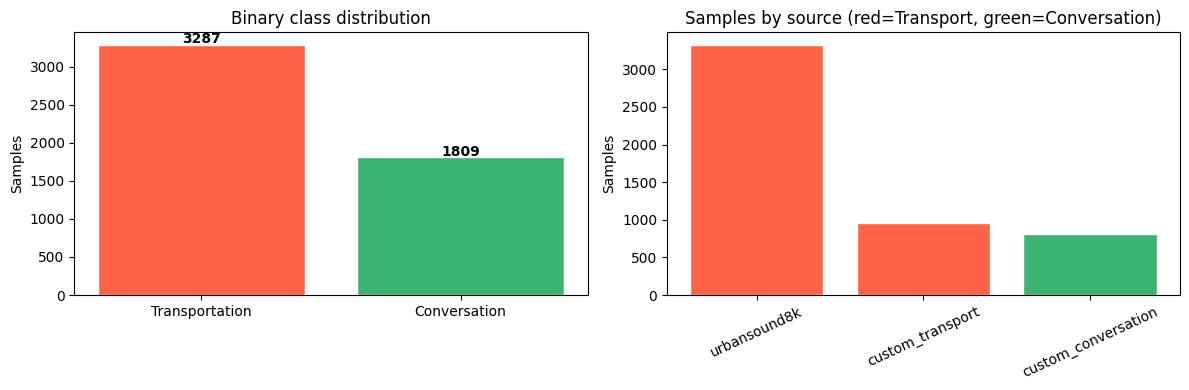

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Binary distribution
counts = [(y == i).sum() for i in [0, 1]]
axes[0].bar(list(LABEL_NAMES.values()), counts,
            color=[COLORS[0], COLORS[1]], edgecolor='white')
axes[0].set_title('Binary class distribution')
axes[0].set_ylabel('Samples')
for i, (name, cnt) in enumerate(zip(LABEL_NAMES.values(), counts)):
    axes[0].text(i, cnt + 20, str(cnt), ha='center', fontweight='bold')

# By data source
src_counts = meta.groupby('source').size().sort_values(ascending=False)
src_colors = [
    'mediumseagreen' if 'conv' in s else 'tomato'
    for s in src_counts.index
]
axes[1].bar(src_counts.index, src_counts.values, color=src_colors, edgecolor='white')
axes[1].set_title('Samples by source (red=Transport, green=Conversation)')
axes[1].set_ylabel('Samples')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## 3. Stratified 80/20 train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train : {X_train.shape}')
print(f'  Transportation: {(y_train==0).sum()}  Conversation: {(y_train==1).sum()}')
print()
print(f'Test  : {X_test.shape}')
print(f'  Transportation: {(y_test==0).sum()}   Conversation: {(y_test==1).sum()}')

np.save(os.path.join(SPLIT_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(SPLIT_DIR, 'X_test.npy'),  X_test)
np.save(os.path.join(SPLIT_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(SPLIT_DIR, 'y_test.npy'),  y_test)
print('\nSaved train/test splits to', SPLIT_DIR)

Train : (4076, 128, 173)
  Transportation: 2629  Conversation: 1447

Test  : (1020, 128, 173)
  Transportation: 658   Conversation: 362

Saved train/test splits to ../data/processed/train_test_split


## 4. Visual sanity check — random samples per class

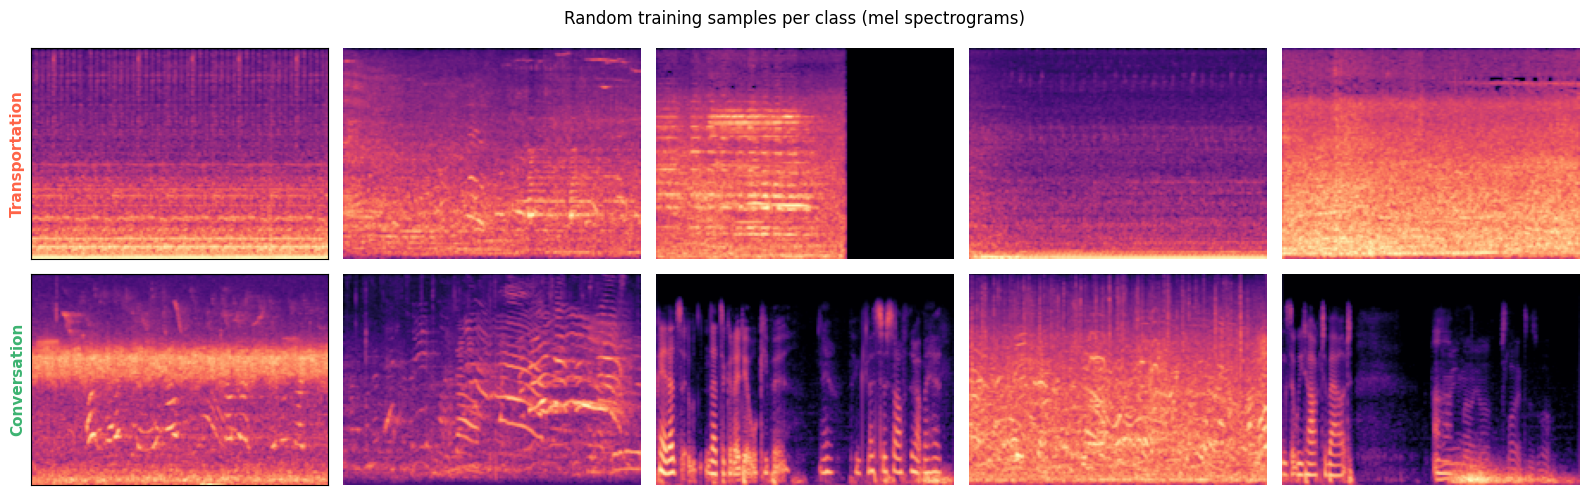

In [5]:
rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 5, figsize=(16, 5))

for row, label_id in enumerate([0, 1]):
    idxs = np.where(y_train == label_id)[0]
    chosen = rng.choice(idxs, size=5, replace=False)
    for col, idx in enumerate(chosen):
        ax = axes[row, col]
        ax.imshow(X_train[idx], aspect='auto', origin='lower', cmap='magma')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(LABEL_NAMES[label_id], color=COLORS[label_id],
                          fontweight='bold', fontsize=11)
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle('Random training samples per class (mel spectrograms)', fontsize=12)
plt.tight_layout()
plt.show()